In [18]:
# Edge AI Energy Efficiency Project - PyTorch Analysis Notebook
# importing the required libraries
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importing PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim

# torchvision is used here to load the MNIST dataset
from torchvision import datasets, transforms
# dataLoader helps us load the data in batches
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report

In [19]:
# create project folders
folders = ["models", "results", "plots"]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created or already exist:", folders)

Folders created or already exist: ['models', 'results', 'plots']


In [20]:
# if GPU is not available, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# loading MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
# batch_size means how many images the model sees at one time
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [22]:
# PyTorch model
# the input image size is 28 x 28, so the total input features are 784
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()

        # this changes the 28x28 image into one long vector
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)

        return x

# creating the model and sending it to CPU
model = MNISTModel().to(device)

print(model)

MNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [23]:
# train the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# number of times the model goes through the training dataset
epochs = 5

train_losses = []
train_accuracies = []

start_time = time.time()

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # calculating average loss and accuracy for this epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

training_time = time.time() - start_time

print("Training completed")
print("Training time:", round(training_time, 2), "seconds")

Epoch [1/5] - Loss: 0.2625, Accuracy: 92.19%
Epoch [2/5] - Loss: 0.1074, Accuracy: 96.71%
Epoch [3/5] - Loss: 0.0758, Accuracy: 97.62%
Epoch [4/5] - Loss: 0.0581, Accuracy: 98.17%
Epoch [5/5] - Loss: 0.0462, Accuracy: 98.52%
Training completed
Training time: 69.08 seconds


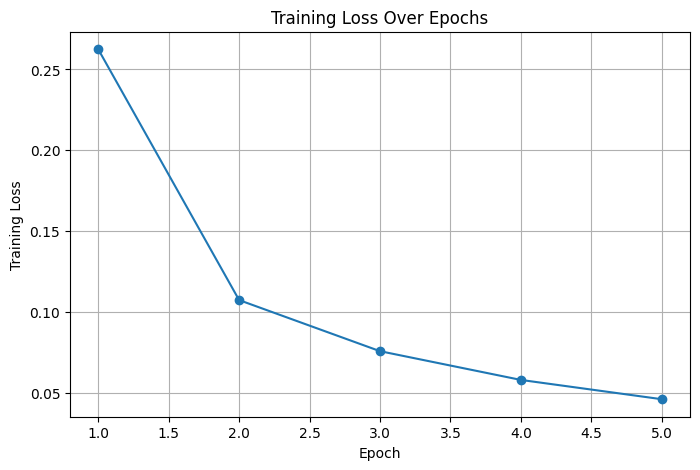

In [24]:
# graph for training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.savefig("plots/training_loss.png")
plt.show()

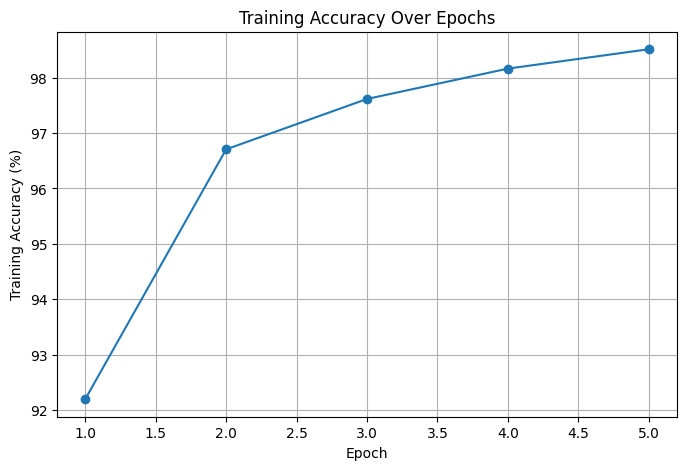

In [25]:
# graph for training accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Over Epochs")
plt.grid(True)
plt.savefig("plots/training_accuracy.png")
plt.show()

In [32]:
# model evaluation and quantization
def evaluate_model(model, data_loader, device):
    model.eval()

    correct = 0
    total = 0

    start_time = time.time()

    # no_grad is used because we are only testing the model
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    inference_time = time.time() - start_time
    accuracy = 100 * correct / total

    return accuracy, inference_time

In [34]:
# evaluating the original PyTorch model on the test dataset
original_model_path = "models/mnist_pytorch_model.pt"
torch.save(model.state_dict(), original_model_path)

# checking original model size in KB
original_model_size = os.path.getsize(original_model_path) / 1024

print("Original model saved at:", original_model_path)
print("Original model size:", round(original_model_size, 2), "KB")

Original model saved at: models/mnist_pytorch_model.pt
Original model size: 430.41 KB


In [35]:
# applying dynamic quantization which reduces the model size
model_cpu = copy.deepcopy(model).to("cpu")
quantized_model = torch.quantization.quantize_dynamic(
    model_cpu,
    {nn.Linear},
    dtype=torch.qint8
)

print("Quantized model created")
print(quantized_model)

Quantized model created
MNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): DynamicQuantizedLinear(in_features=784, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (relu1): ReLU()
  (fc2): DynamicQuantizedLinear(in_features=128, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (relu2): ReLU()
  (fc3): DynamicQuantizedLinear(in_features=64, out_features=10, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
)


/tmp/ipykernel_38793/70847374.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [36]:
# saving the quantized model
quantized_model_path = "models/quantized_model.pt"
torch.save(quantized_model.state_dict(), quantized_model_path)

# checking quantized model size in KB
quantized_model_size = os.path.getsize(quantized_model_path) / 1024

print("Quantized model saved at:", quantized_model_path)
print("Quantized model size:", round(quantized_model_size, 2), "KB")

Quantized model saved at: models/quantized_model.pt
Quantized model size: 112.39 KB


In [39]:
# quantized model is evaluated on CPU
quantized_accuracy, quantized_inference_time = evaluate_model(
    quantized_model,
    test_loader,
    torch.device("cpu")
)

print("Quantized Model Accuracy:", round(quantized_accuracy, 2), "%")
print("Quantized Model Inference Time:", round(quantized_inference_time, 4), "seconds")

Quantized Model Accuracy: 97.69 %
Quantized Model Inference Time: 2.3427 seconds


In [40]:
# comparing the original and quantized models
comparison_data = {
    "Model": ["Original PyTorch Model", "Quantized PyTorch Model"],
    "Accuracy (%)": [original_accuracy, quantized_accuracy],
    "Inference Time (seconds)": [original_inference_time, quantized_inference_time],
    "Model Size (KB)": [original_model_size, quantized_model_size]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv("results/model_comparison.csv", index=False)
comparison_df

,Model,Accuracy (%),Inference Time (seconds),Model Size (KB)
0,Original PyTorch Model,97.72,2.213231,430.411133
1,Quantized PyTorch Model,97.69,2.342739,112.389648


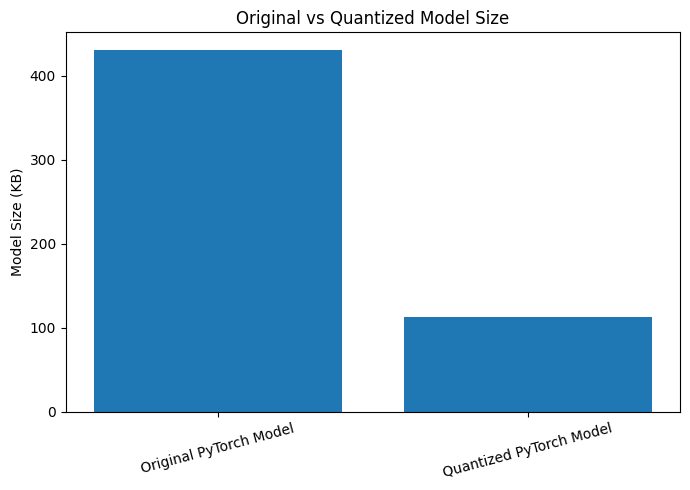

In [42]:
# plotting model size comparison - smaller model size means the model is better for edge deployment

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Original vs Quantized Model Size")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plots/model_size_comparison.png")
plt.show()

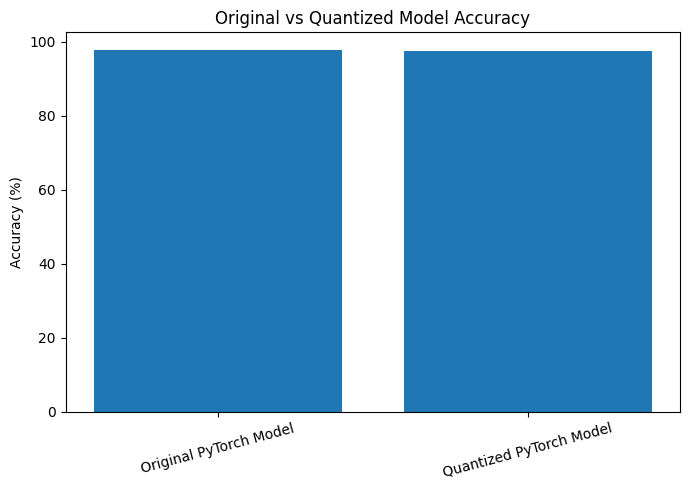

In [43]:
# plotting accuracy comparison

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy (%)"])
plt.ylabel("Accuracy (%)")
plt.title("Original vs Quantized Model Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plots/accuracy_comparison.png")
plt.show()

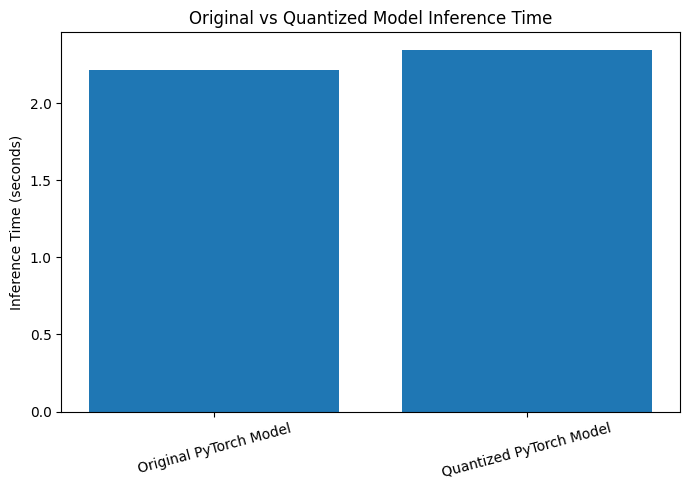

In [44]:
# plotting inference time comparison - comparing how fast the original and quantized models run

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Inference Time (seconds)"])
plt.ylabel("Inference Time (seconds)")
plt.title("Original vs Quantized Model Inference Time")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plots/inference_time_comparison.png")
plt.show()

In [50]:
# simulate multiple edge devices where each device gets a small part of the test dataset
num_devices = 5
samples_per_device = 1000

edge_results = []

for device_id in range(num_devices):
    start_index = device_id * samples_per_device
    end_index = start_index + samples_per_device

    # selecting a different part of the test dataset for each device
    device_subset = Subset(test_dataset, range(start_index, end_index))

    device_loader = DataLoader(
        device_subset,
        batch_size=100,
        shuffle=False
    )

    # testing the quantized model
    accuracy, inference_time = evaluate_model(
        quantized_model,
        device_loader,
        torch.device("cpu")
    )

    edge_results.append({
        "Edge Device": f"Device {device_id + 1}",
        "Samples Processed": samples_per_device,
        "Accuracy (%)": accuracy,
        "Inference Time (seconds)": inference_time
    })

edge_df = pd.DataFrame(edge_results)

edge_df.to_csv("results/edge_device_simulation.csv", index=False)

edge_df

,Edge Device,Samples Processed,Accuracy (%),Inference Time (seconds)
0,Device 1,1000,97.8,0.183587
1,Device 2,1000,95.7,0.186527
2,Device 3,1000,96.0,0.217871
3,Device 4,1000,97.2,0.574641
4,Device 5,1000,97.2,0.529639


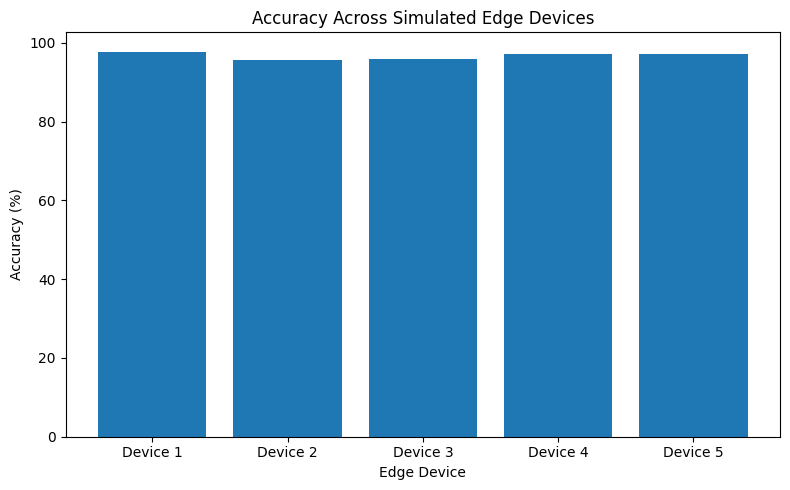

In [51]:
# plotting accuracy

plt.figure(figsize=(8, 5))
plt.bar(edge_df["Edge Device"], edge_df["Accuracy (%)"])
plt.xlabel("Edge Device")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Across Simulated Edge Devices")
plt.tight_layout()
plt.savefig("plots/edge_device_accuracy.png")
plt.show()

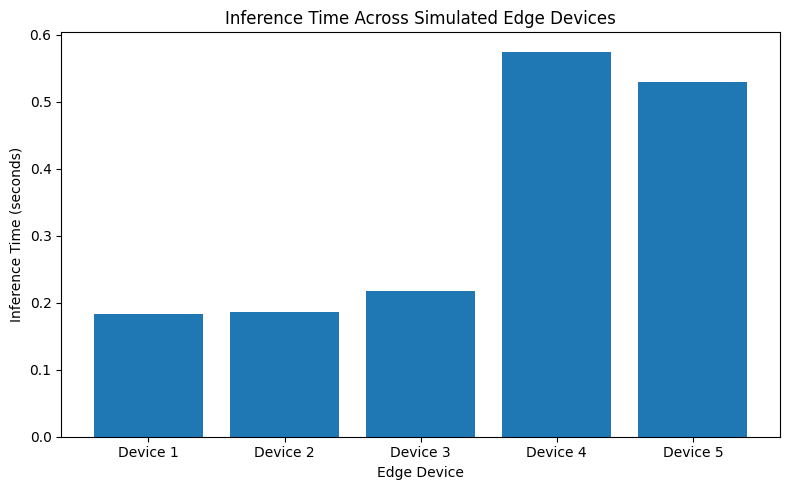

In [52]:
# plotting inference time

plt.figure(figsize=(8, 5))
plt.bar(edge_df["Edge Device"], edge_df["Inference Time (seconds)"])
plt.xlabel("Edge Device")
plt.ylabel("Inference Time (seconds)")
plt.title("Inference Time Across Simulated Edge Devices")
plt.tight_layout()
plt.savefig("plots/edge_device_inference_time.png")
plt.show()

In [54]:
# communication cost analysis
communication_data = {
    "Model": ["Original PyTorch Model", "Quantized PyTorch Model"],
    "Estimated Communication Cost (KB)": [
        original_model_size,
        quantized_model_size
    ]
}
communication_df = pd.DataFrame(communication_data)
communication_df.to_csv("results/communication_cost.csv", index=False)
communication_df

,Model,Estimated Communication Cost (KB)
0,Original PyTorch Model,430.411133
1,Quantized PyTorch Model,112.389648


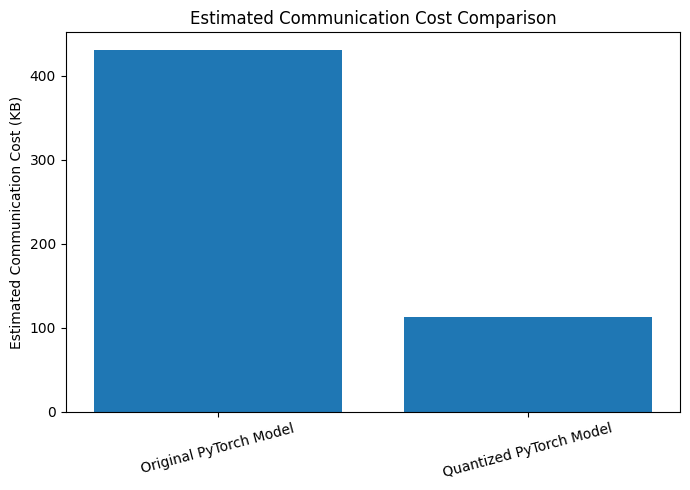

In [55]:
# plotting communication cost comparison

plt.figure(figsize=(7, 5))
plt.bar(
    communication_df["Model"],
    communication_df["Estimated Communication Cost (KB)"]
)
plt.ylabel("Estimated Communication Cost (KB)")
plt.title("Estimated Communication Cost Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plots/communication_cost_comparison.png")
plt.show()

In [59]:
# federated learning communication estimate
device_counts = [1, 5, 10, 20]

federated_results = []

for count in device_counts:
    original_total_cost = original_model_size * count
    quantized_total_cost = quantized_model_size * count

    reduction = original_total_cost - quantized_total_cost
    reduction_percent = (reduction / original_total_cost) * 100

    federated_results.append({
        "Number of Edge Devices": count,
        "Original Model Communication Cost (KB)": original_total_cost,
        "Quantized Model Communication Cost (KB)": quantized_total_cost,
        "Reduction (%)": reduction_percent
    })

federated_df = pd.DataFrame(federated_results)
federated_df.to_csv("results/federated_communication_estimate.csv", index=False)
federated_df

,Number of Edge Devices,Original Model Communication Cost (KB),Quantized Model Communication Cost (KB),Reduction (%)
0,1,430.411133,112.389648,73.887839
1,5,2152.055664,561.948242,73.887839
2,10,4304.111328,1123.896484,73.887839
3,20,8608.222656,2247.792969,73.887839


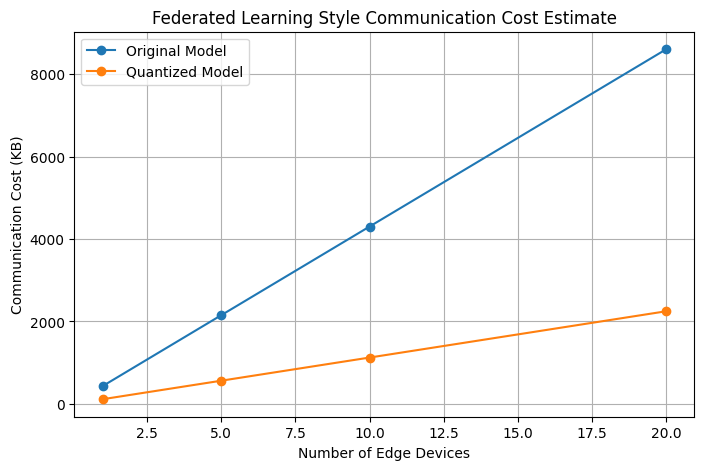

In [62]:
# plotting federated communication cost estimate
plt.figure(figsize=(8, 5))
plt.plot(
    federated_df["Number of Edge Devices"],
    federated_df["Original Model Communication Cost (KB)"],
    marker="o",
    label="Original Model"
)
plt.plot(
    federated_df["Number of Edge Devices"],
    federated_df["Quantized Model Communication Cost (KB)"],
    marker="o",
    label="Quantized Model"
)
plt.xlabel("Number of Edge Devices")
plt.ylabel("Communication Cost (KB)")
plt.title("Federated Learning Style Communication Cost Estimate")
plt.legend()
plt.grid(True)
plt.savefig("plots/federated_communication_cost.png")
plt.show()

In [63]:
# final summary
print("Project Analysis Completed")
print("----------------------------------")
print("Original Accuracy:", round(original_accuracy, 2), "%")
print("Quantized Accuracy:", round(quantized_accuracy, 2), "%")
print("Original Model Size:", round(original_model_size, 2), "KB")
print("Quantized Model Size:", round(quantized_model_size, 2), "KB")
print("Original Inference Time:", round(original_inference_time, 4), "seconds")
print("Quantized Inference Time:", round(quantized_inference_time, 4), "seconds")
print("----------------------------------")
print("Saved output files:")
print("models/mnist_pytorch_model.pt")
print("models/quantized_model.pt")
print("results/model_comparison.csv")
print("results/edge_device_simulation.csv")
print("results/communication_cost.csv")
print("results/federated_communication_estimate.csv")
print("plots/")

Project Analysis Completed
----------------------------------
Original Accuracy: 97.72 %
Quantized Accuracy: 97.69 %
Original Model Size: 430.41 KB
Quantized Model Size: 112.39 KB
Original Inference Time: 2.2132 seconds
Quantized Inference Time: 2.3427 seconds
----------------------------------
Saved output files:
models/mnist_pytorch_model.pt
models/quantized_model.pt
results/model_comparison.csv
results/edge_device_simulation.csv
results/communication_cost.csv
results/federated_communication_estimate.csv
plots/
